# Простейшие задачи распознавания образов: полносвязная нейронная сеть

Лабораторная работа № 1 по дисциплине «Методы машинного обучения».
Московский Политех, группа 231-329, Арутюнян Ф. Р.

**Как я понял задачу.** Текста задания в СДО нет. Беру стандартное содержание такой работы:
обучить полносвязную нейронную сеть распознавать изображения, показать кривые точности и потерь
по эпохам, матрицу ошибок, примеры верных и неверных распознаваний, а также проверить, как
на результат влияют число эпох и число слоёв. Преподаватель отдельно упоминала этап верификации,
поэтому часть данных я откладываю заранее и не трогаю до самого конца.

**Данные.** Fashion-MNIST: 70 000 чёрно-белых изображений одежды размером 28 на 28 пикселей,
10 классов. Это усложнённая замена набора рукописных цифр MNIST: на цифрах любая сеть даёт
больше 97 %, и разницу между архитектурами не разглядеть.

**План работы:**
1. Загрузка набора и просмотр примеров.
2. Подготовка данных и разбиение, включая отложенную выборку для верификации.
3. Сеть с одним скрытым слоем.
4. Сеть с тремя скрытыми слоями и дропаутом.
5. Влияние числа эпох и числа слоёв.
6. Оценка лучшей сети: метрики по классам, матрица ошибок, разбор ошибок.
7. Этап верификации на отложенных примерах.

## 0. Библиотеки и настройки

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             precision_recall_fscore_support)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Устройство:', device)


def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=150, bbox_inches='tight')

Устройство: mps


## 1. Набор данных

Fashion-MNIST скачивается через torchvision при первом запуске. В обучающей части 60 000
изображений, в тестовой 10 000. Каждое изображение это матрица 28 на 28 значений яркости
от 0 до 255.

Нормализация: значения делятся на 255 и приводятся к среднему 0,286 и отклонению 0,353,
посчитанным по обучающей части. Сеть с нормализованными входами обучается устойчивее.

In [2]:
CLASSES = ['футболка', 'брюки', 'свитер', 'платье', 'пальто',
           'сандалии', 'рубашка', 'кроссовки', 'сумка', 'ботинки']

tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.2860,), (0.3530,))])

train_full = datasets.FashionMNIST('data', train=True, download=True, transform=tf)
test_full = datasets.FashionMNIST('data', train=False, download=True, transform=tf)

print('Обучающая часть:', len(train_full), 'тестовая часть:', len(test_full))
print('Размер изображения:', tuple(train_full[0][0].shape))

0.1%

0.2%

0.4%

0.5%

0.6%

...

98.6%

99.3%

100.0%

100.0%

Обучающая часть: 60000 тестовая часть: 10000
Размер изображения: (1, 28, 28)


/var/folders/c2/l_fldtkj3cz5l1bmjq0nr7qc0000gp/T/ipykernel_25906/2058638947.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  idx = np.where(np.array(raw_train.targets) == k)[0][0]


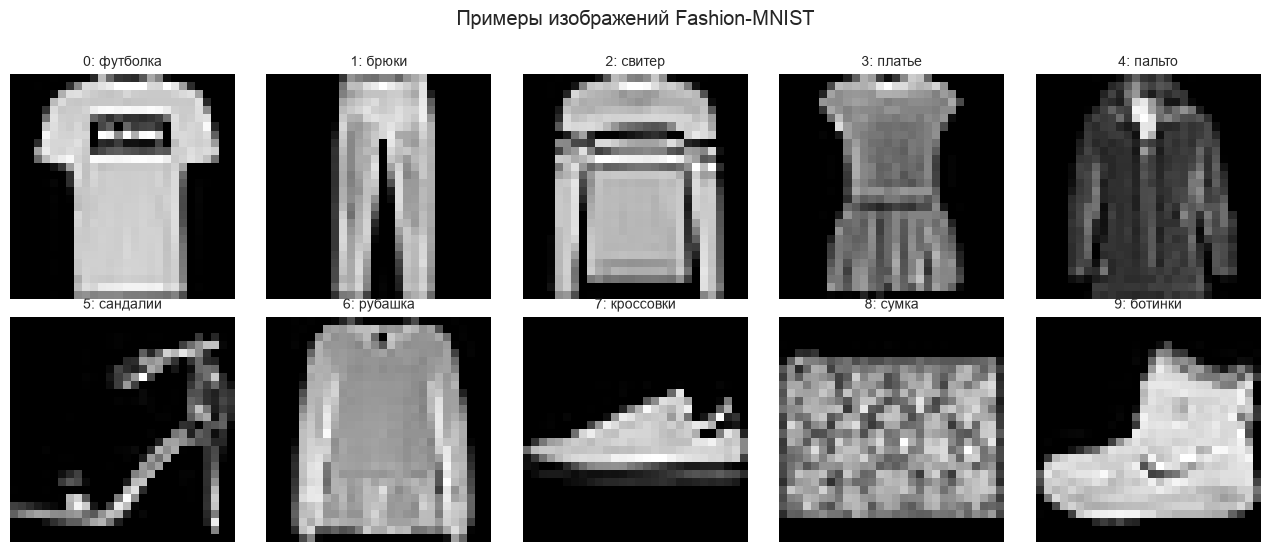

In [3]:
raw_train = datasets.FashionMNIST('data', train=True, download=False)
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
for k, ax in enumerate(axes.ravel()):
    idx = np.where(np.array(raw_train.targets) == k)[0][0]
    ax.imshow(raw_train.data[idx], cmap='gray')
    ax.set_title(f'{k}: {CLASSES[k]}', fontsize=10)
    ax.axis('off')
fig.suptitle('Примеры изображений Fashion-MNIST', y=1.0)
fig.tight_layout()
save_fig('01_samples.png')
plt.show()

**Рисунок 1 — Примеры изображений каждого класса**

Классы отличаются формой силуэта, но обувь, сумки и верхняя одежда занимают примерно одинаковую часть кадра, а свитер, рубашка и пальто похожи даже на глаз.

/var/folders/c2/l_fldtkj3cz5l1bmjq0nr7qc0000gp/T/ipykernel_25906/2516077636.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  counts = pd.Series(np.array(train_full.targets)).value_counts().sort_index()


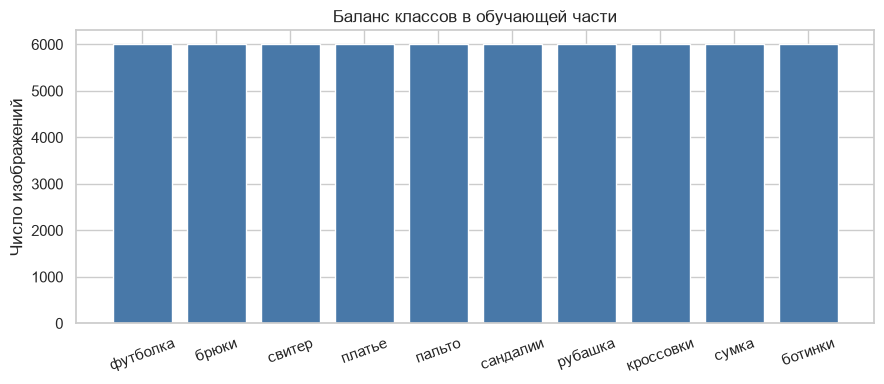

{'футболка': 6000, 'брюки': 6000, 'свитер': 6000, 'платье': 6000, 'пальто': 6000, 'сандалии': 6000, 'рубашка': 6000, 'кроссовки': 6000, 'сумка': 6000, 'ботинки': 6000}


In [4]:
counts = pd.Series(np.array(train_full.targets)).value_counts().sort_index()
counts.index = CLASSES
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(counts.index, counts.values, color='#4878a8')
ax.set_ylabel('Число изображений')
ax.set_title('Баланс классов в обучающей части')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
save_fig('02_balance.png')
plt.show()
print(counts.to_dict())

**Рисунок 2 — Баланс классов**

Классы идеально сбалансированы, по 6000 изображений каждый, поэтому accuracy сравнима между классами.

## 2. Разбиение и отложенная выборка для верификации

Обучающие 60 000 изображений делю на 54 000 для обучения и 6 000 для валидации: по валидации
выбираю лучшую эпоху и сравниваю архитектуры.

Тестовые 10 000 делю на две части. Первые 9 000 это тестовая выборка, на ней считаю метрики.
Последние 1 000 откладываю для **этапа верификации**: эти изображения не участвуют ни в обучении,
ни в выборе архитектуры, ни в подсчёте метрик, и я обращаюсь к ним один раз в самом конце работы.

In [5]:
g = torch.Generator().manual_seed(RANDOM_STATE)
train_ds, val_ds = torch.utils.data.random_split(train_full, [54000, 6000], generator=g)

test_ds = Subset(test_full, range(9000))
verify_ds = Subset(test_full, range(9000, 10000))

BATCH = 128
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=512)
test_dl = DataLoader(test_ds, batch_size=512)
verify_dl = DataLoader(verify_ds, batch_size=512)

print(f'обучение {len(train_ds)}, валидация {len(val_ds)}, '
      f'тест {len(test_ds)}, верификация {len(verify_ds)}')

обучение 54000, валидация 6000, тест 9000, верификация 1000


## 3. Полносвязная сеть

Полносвязная сеть не знает, что вход это картинка: изображение 28 на 28 разворачивается
в вектор из 784 чисел. Каждый нейрон слоя считает взвешенную сумму всех входов и пропускает
её через функцию активации ReLU, которая обнуляет отрицательные значения и добавляет нелинейность.
Последний слой выдаёт 10 чисел, по одному на класс.

Сеть собираю с произвольным числом скрытых слоёв, чтобы сравнить архитектуры.

In [6]:
class MLP(nn.Module):
    def __init__(self, hidden=(128,), dropout=0.0):
        super().__init__()
        layers = [nn.Flatten()]
        prev = 28 * 28
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train_mode):
            out = model(x)
            loss = criterion(out, y)
        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total


def fit(model, epochs=20, lr=1e-3, quiet=False):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc, best_state = 0.0, None
    t0 = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_dl, criterion)
        for k, v in zip(history, [tr_loss, tr_acc, va_loss, va_acc]):
            history[k].append(v)
        if va_acc > best_acc:
            best_acc, best_state = va_acc, {k: v.detach().clone() for k, v in model.state_dict().items()}
        if not quiet:
            print(f'эпоха {ep:2}: потери {tr_loss:.3f}/{va_loss:.3f}, точность {tr_acc:.3f}/{va_acc:.3f}')
    model.load_state_dict(best_state)
    print(f'обучение заняло {time.time() - t0:.0f} с, лучшая точность на валидации {best_acc:.4f}')
    return history

### 3.1 Сеть с одним скрытым слоем

Первая архитектура: 784 входа, один скрытый слой из 128 нейронов, выход из 10 нейронов.
Обучаю 20 эпох оптимизатором Adam с шагом 0,001.

In [7]:
net1 = MLP(hidden=(128,)).to(device)
print(net1)
print(f'Параметров: {sum(p.numel() for p in net1.parameters()):,}')
history1 = fit(net1, epochs=20)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)
Параметров: 101,770


эпоха  1: потери 0.499/0.406, точность 0.820/0.852


эпоха  2: потери 0.373/0.367, точность 0.865/0.865


эпоха  3: потери 0.335/0.348, точность 0.877/0.872


эпоха  4: потери 0.309/0.364, точность 0.886/0.869


...

эпоха 16: потери 0.175/0.325, точность 0.935/0.895


эпоха 17: потери 0.169/0.331, точность 0.937/0.896


эпоха 18: потери 0.164/0.345, точность 0.938/0.888


эпоха 19: потери 0.159/0.349, точность 0.941/0.890


эпоха 20: потери 0.153/0.371, точность 0.943/0.883
обучение заняло 61 с, лучшая точность на валидации 0.8957


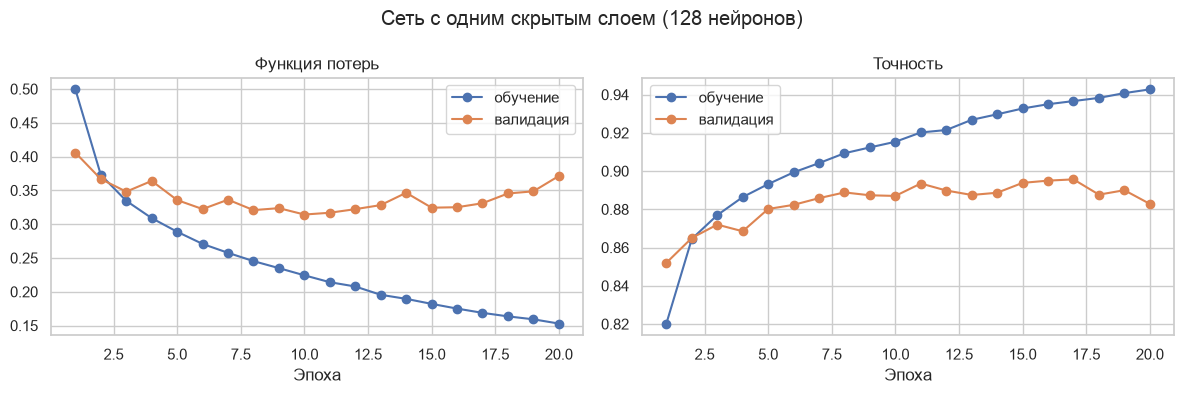

In [8]:
def plot_history(history, title, fname):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(history['train_loss']) + 1)
    axes[0].plot(ep, history['train_loss'], 'o-', label='обучение')
    axes[0].plot(ep, history['val_loss'], 'o-', label='валидация')
    axes[0].set_title('Функция потерь')
    axes[0].set_xlabel('Эпоха')
    axes[0].legend()
    axes[1].plot(ep, history['train_acc'], 'o-', label='обучение')
    axes[1].plot(ep, history['val_acc'], 'o-', label='валидация')
    axes[1].set_title('Точность')
    axes[1].set_xlabel('Эпоха')
    axes[1].legend()
    fig.suptitle(title)
    fig.tight_layout()
    save_fig(fname)
    plt.show()


plot_history(history1, 'Сеть с одним скрытым слоем (128 нейронов)', '03_net1_training.png')

**Рисунок 3 — Кривые обучения сети с одним скрытым слоем**

Точность на обучении растёт до 0,943, а на валидации останавливается около 0,89 после десятой эпохи и дальше колеблется: сеть с одним слоем начинает запоминать обучающие изображения.

### 3.2 Сеть с тремя скрытыми слоями

Вторая архитектура: три скрытых слоя по 256, 128 и 64 нейрона и дропаут 0,2 после каждого.
Дропаут во время обучения случайно обнуляет пятую часть нейронов, чтобы сеть не полагалась
на отдельные признаки.

In [9]:
torch.manual_seed(RANDOM_STATE)
net3 = MLP(hidden=(256, 128, 64), dropout=0.2).to(device)
print(f'Параметров: {sum(p.numel() for p in net3.parameters()):,}')
history3 = fit(net3, epochs=20)

Параметров: 242,762


эпоха  1: потери 0.612/0.428, точность 0.780/0.844


эпоха  2: потери 0.416/0.374, точность 0.852/0.864


эпоха  3: потери 0.375/0.356, точность 0.865/0.874


эпоха  4: потери 0.352/0.339, точность 0.874/0.875


...

эпоха 16: потери 0.239/0.302, точность 0.911/0.893


эпоха 17: потери 0.230/0.307, точность 0.914/0.894


эпоха 18: потери 0.227/0.296, точность 0.916/0.898


эпоха 19: потери 0.225/0.305, точность 0.915/0.896


эпоха 20: потери 0.219/0.318, точность 0.919/0.891
обучение заняло 67 с, лучшая точность на валидации 0.8982


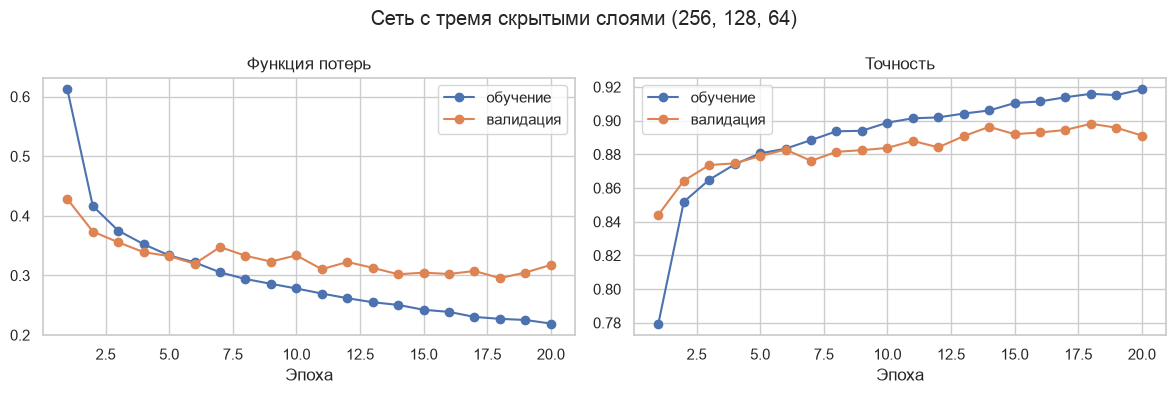

In [10]:
plot_history(history3, 'Сеть с тремя скрытыми слоями (256, 128, 64)', '04_net3_training.png')

**Рисунок 4 — Кривые обучения сети с тремя скрытыми слоями**

С тремя слоями и дропаутом кривые идут ближе друг к другу: на двадцатой эпохе точность на обучении 0,919 против 0,891 на валидации, тогда как у сети с одним слоем разрыв 0,943 против 0,883. Лучшая точность на валидации выше на 0,25 процентного пункта.

## 4. Влияние числа эпох и числа слоёв

Точность на валидации после каждой эпохи уже посчитана, поэтому влияние числа эпох видно
прямо из истории обучения. Сравниваю обе архитектуры на одном графике.

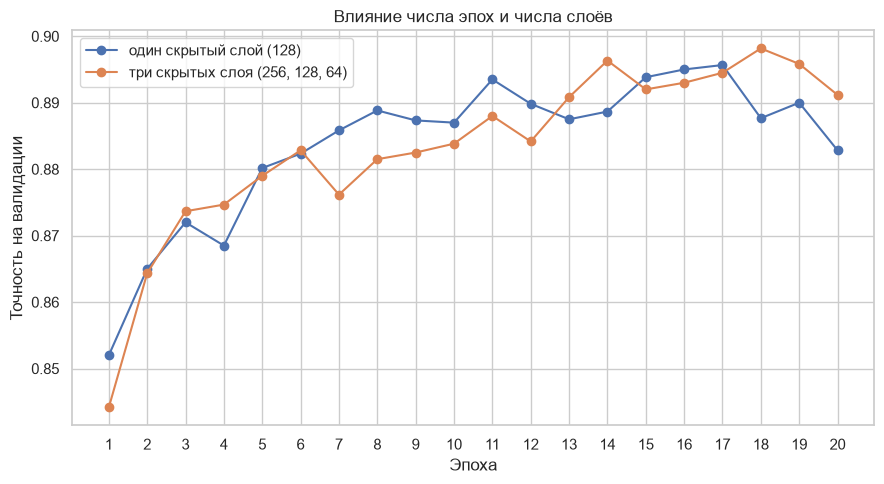

,Один слой,Три слоя
1 эпох,0.8520,0.8442
5 эпох,0.8802,0.8790
10 эпох,0.8870,0.8838
15 эпох,0.8938,0.8920
20 эпох,0.8828,0.8912


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ep = range(1, 21)
ax.plot(ep, history1['val_acc'], 'o-', label='один скрытый слой (128)')
ax.plot(ep, history3['val_acc'], 'o-', label='три скрытых слоя (256, 128, 64)')
ax.set_xlabel('Эпоха')
ax.set_ylabel('Точность на валидации')
ax.set_title('Влияние числа эпох и числа слоёв')
ax.set_xticks(list(ep))
ax.legend()
fig.tight_layout()
save_fig('05_epochs_layers.png')
plt.show()

table = pd.DataFrame({
    'Один слой': [history1['val_acc'][e - 1] for e in (1, 5, 10, 15, 20)],
    'Три слоя': [history3['val_acc'][e - 1] for e in (1, 5, 10, 15, 20)],
}, index=[f'{e} эпох' for e in (1, 5, 10, 15, 20)])
table.round(4)

**Рисунок 5 — Точность на валидации по эпохам для двух архитектур**

Обе архитектуры выходят на плато к десятой эпохе (0,8870 и 0,8838), дальше точность на валидации колеблется в пределах процентного пункта, а три слоя дают лишь небольшой выигрыш по лучшей эпохе (0,8982 против 0,8957).

## 5. Оценка лучшей сети

Лучшей считаю архитектуру с большей точностью на валидации и проверяю её на тестовой выборке
из 9000 изображений.

In [12]:
best_net, best_name = ((net3, 'три скрытых слоя') if max(history3['val_acc']) > max(history1['val_acc'])
                       else (net1, 'один скрытый слой'))
print('Лучшая архитектура:', best_name)


def predict(model, loader):
    model.eval()
    ys, preds, probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            p = torch.softmax(out, dim=1).cpu().numpy()
            probs.append(p)
            preds.append(p.argmax(1))
            ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(preds), np.concatenate(probs)


criterion = nn.CrossEntropyLoss()
test_loss, test_acc = run_epoch(best_net, test_dl, criterion)
y_true, y_pred, y_prob = predict(best_net, test_dl)
print(f'Точность на тесте: {test_acc:.4f}, ошибка: {test_loss:.4f}\n')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

Лучшая архитектура: три скрытых слоя


Точность на тесте: 0.8879, ошибка: 0.3300

              precision    recall  f1-score   support

    футболка     0.8557    0.8442    0.8499       892
       брюки     0.9808    0.9775    0.9792       890
      свитер     0.8472    0.7657    0.8044       905
      платье     0.8709    0.9203    0.8949       916
      пальто     0.7968    0.8072    0.8020       913
    сандалии     0.9642    0.9589    0.9616       900
     рубашка     0.7138    0.7267    0.7202       889
   кроссовки     0.9325    0.9571    0.9447       910
       сумка     0.9600    0.9752    0.9675       886
     ботинки     0.9583    0.9466    0.9524       899

    accuracy                         0.8879      9000
   macro avg     0.8880    0.8879    0.8877      9000
weighted avg     0.8879    0.8879    0.8876      9000



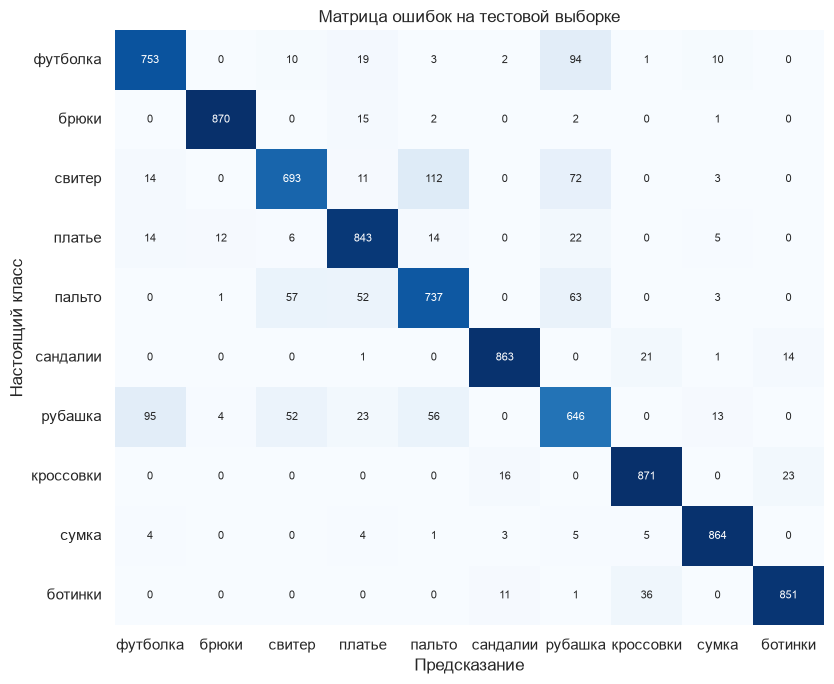

Самые частые путаницы:
  свитер → пальто: 112
  рубашка → футболка: 95
  футболка → рубашка: 94
  свитер → рубашка: 72
  пальто → рубашка: 63


In [13]:
fig, ax = plt.subplots(figsize=(8.5, 7))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, annot_kws={'size': 8})
ax.set_xlabel('Предсказание')
ax.set_ylabel('Настоящий класс')
ax.set_title('Матрица ошибок на тестовой выборке')
fig.tight_layout()
save_fig('06_confusion.png')
plt.show()

pairs = [(CLASSES[i], CLASSES[j], cm[i, j]) for i in range(10) for j in range(10) if i != j]
print('Самые частые путаницы:')
for a, b, n in sorted(pairs, key=lambda t: -t[2])[:5]:
    print(f'  {a} → {b}: {n}')

**Рисунок 6 — Матрица ошибок лучшей сети**

Почти все ошибки приходятся на верхнюю одежду: свитер путается с пальто 112 раз, рубашка с футболкой 95 раз, а обувь и сумки распознаются почти без ошибок.

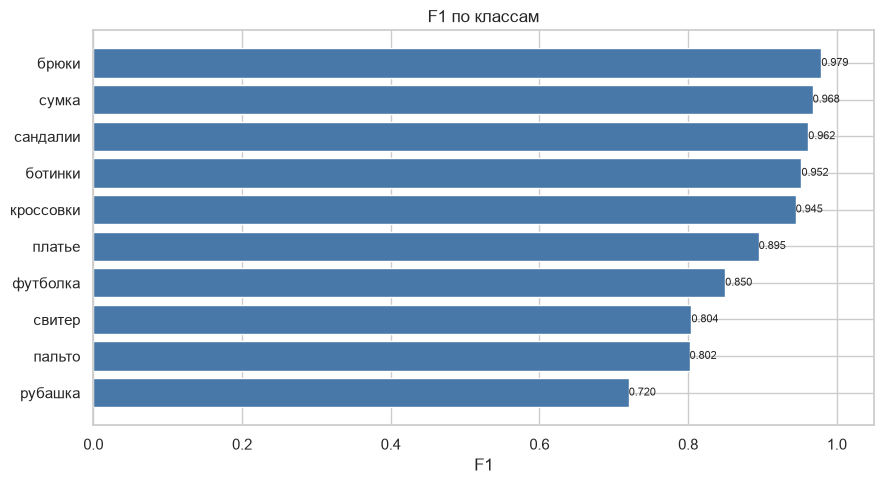

,Precision,Recall,F1
рубашка,0.7138,0.7267,0.7202
пальто,0.7968,0.8072,0.8020
свитер,0.8472,0.7657,0.8044
футболка,0.8557,0.8442,0.8499
платье,0.8709,0.9203,0.8949
кроссовки,0.9325,0.9571,0.9447
ботинки,0.9583,0.9466,0.9524
сандалии,0.9642,0.9589,0.9616
сумка,0.9600,0.9752,0.9675
брюки,0.9808,0.9775,0.9792


In [14]:
pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
per_class = pd.DataFrame({'Precision': pr, 'Recall': rc, 'F1': f1}, index=CLASSES).sort_values('F1')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(per_class.index, per_class['F1'], color='#4878a8')
ax.bar_label(bars, fmt='%.3f', fontsize=8)
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1')
ax.set_title('F1 по классам')
fig.tight_layout()
save_fig('07_per_class.png')
plt.show()
per_class.round(4)

**Рисунок 7 — F1 по классам**

Худший класс рубашка (F1 0,720), она похожа сразу на футболку, свитер и пальто, лучший класс брюки (0,979) с уникальным силуэтом.

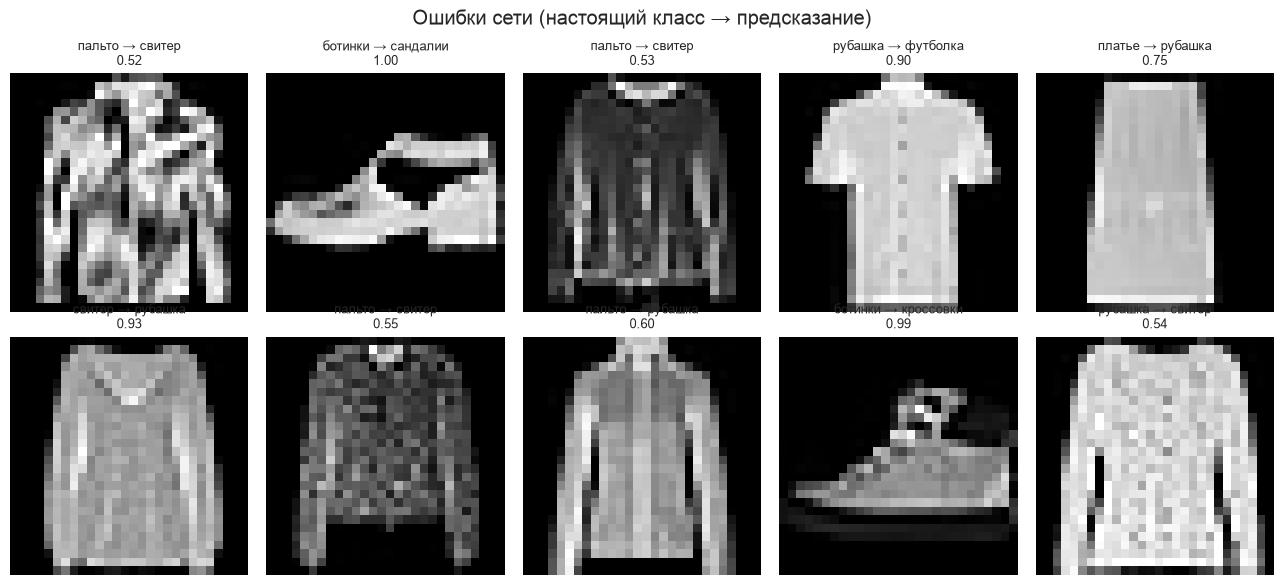

In [15]:
raw_test = datasets.FashionMNIST('data', train=False, download=False)
errors = np.where(y_true != y_pred)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, k in zip(axes.ravel(), errors):
    ax.imshow(raw_test.data[k], cmap='gray')
    ax.axis('off')
    ax.set_title(f'{CLASSES[y_true[k]]} → {CLASSES[y_pred[k]]}\n{y_prob[k].max():.2f}', fontsize=9)
fig.suptitle('Ошибки сети (настоящий класс → предсказание)')
fig.tight_layout()
save_fig('08_errors.png')
plt.show()

**Рисунок 8 — Примеры ошибок сети**

В ошибках видно, что спутанные изображения похожи и для человека: тёмный свитер с длинным рукавом и пальто на картинке 28 на 28 пикселей различаются деталями, которые при таком разрешении теряются.

## 6. Этап верификации

Отложенная тысяча изображений не участвовала ни в обучении, ни в выборе архитектуры,
ни в подсчёте метрик выше. Проверяю на ней лучшую сеть: считаю точность и смотрю на
конкретные ответы с вероятностями.

In [16]:
ver_loss, ver_acc = run_epoch(best_net, verify_dl, criterion)
y_v, pred_v, prob_v = predict(best_net, verify_dl)
print(f'Верификация на 1000 отложенных изображений: точность {ver_acc:.4f}, ошибка {ver_loss:.4f}')
print(f'Для сравнения на тестовой выборке было {test_acc:.4f}')
print(f'Верно распознано {int((y_v == pred_v).sum())} изображений из {len(y_v)}')

Верификация на 1000 отложенных изображений: точность 0.8870, ошибка 0.3057
Для сравнения на тестовой выборке было 0.8879
Верно распознано 887 изображений из 1000


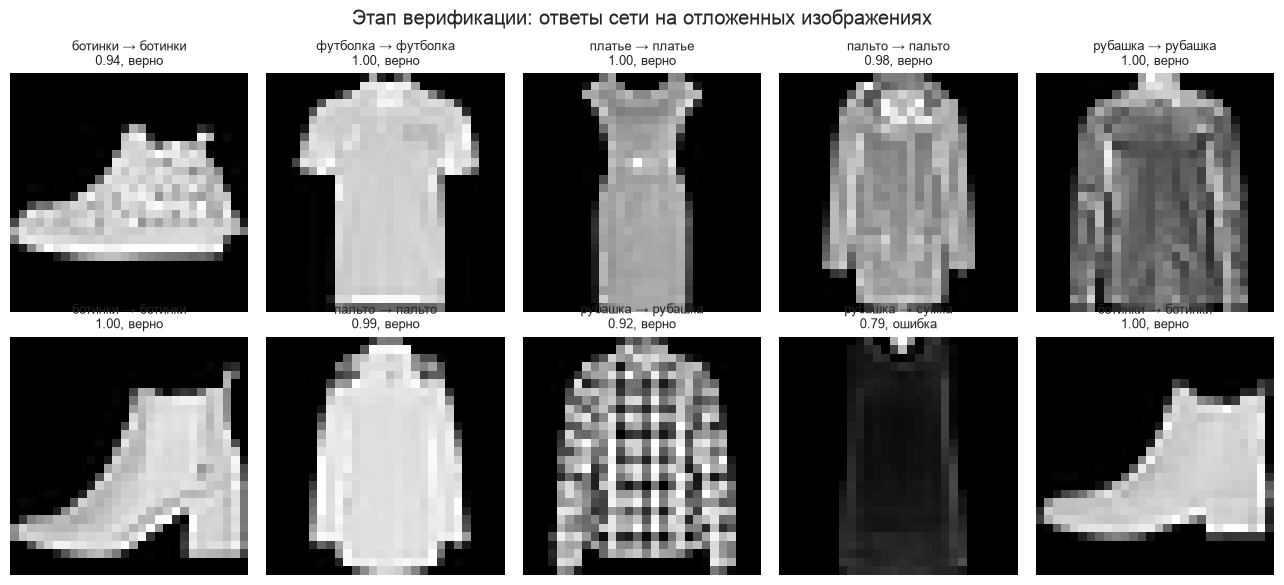

In [17]:
rng = np.random.RandomState(RANDOM_STATE)
picks = rng.choice(len(y_v), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, k in zip(axes.ravel(), picks):
    ax.imshow(raw_test.data[9000 + k], cmap='gray')
    ax.axis('off')
    ok = 'верно' if pred_v[k] == y_v[k] else 'ошибка'
    ax.set_title(f'{CLASSES[y_v[k]]} → {CLASSES[pred_v[k]]}\n{prob_v[k].max():.2f}, {ok}', fontsize=9)
fig.suptitle('Этап верификации: ответы сети на отложенных изображениях')
fig.tight_layout()
save_fig('09_verification.png')
plt.show()

**Рисунок 9 — Этап верификации на отложенных изображениях**

На отложенной тысяче изображений точность 0,8870 против 0,8879 на тесте, разница 0,09 процентного пункта, то есть оценка качества устойчива и сеть не подогнана под тестовую выборку.

## 7. Выводы

1. **Данные.** Fashion-MNIST, 70 000 изображений 28 на 28 пикселей, 10 классов по 7000 штук.
   Разбиение: 54 000 на обучение, 6000 на валидацию, 9000 на тест и 1000 отложены для верификации.

2. **Влияние числа слоёв.** Сеть с одним скрытым слоем из 128 нейронов (101 770 параметров)
   дала на валидации 0,8957, сеть с тремя слоями 256, 128 и 64 с дропаутом (242 762 параметра)
   дала 0,8982. Выигрыш от усложнения всего 0,25 процентного пункта: полносвязная сеть
   не учитывает, что вход это картинка, и лишние слои эту слабость не лечат.

3. **Влияние числа эпох.** Обе сети выходят на плато к десятой эпохе. Дальше точность на обучении
   продолжает расти (до 0,943 у первой сети), а на валидации стоит на месте и колеблется.
   Это переобучение, и лишние эпохи качества не добавляют. Поэтому в конце берутся веса
   лучшей эпохи по валидации, а не последней.

4. **Качество лучшей сети на тесте:** accuracy 0,8879, ошибка 0,3300, средний F1 0,8877
   на 9000 изображениях.

5. **Где ошибки.** Все трудные классы это верхняя одежда: рубашка (F1 0,720), пальто (0,802),
   свитер (0,804). Свитер путается с пальто 112 раз, рубашка с футболкой 95 раз. Обувь, сумки
   и брюки распознаются почти безошибочно (F1 от 0,945 до 0,979), у них уникальный силуэт.

6. **Этап верификации.** На тысяче отложенных изображений, которые не участвовали ни в обучении,
   ни в выборе архитектуры, ни в подсчёте метрик, точность 0,8870 против 0,8879 на тесте.
   Разница 0,09 процентного пункта подтверждает, что оценка устойчива.

7. **Что улучшило бы результат:** свёрточная сеть вместо полносвязной, она учитывает соседство
   пикселей и на Fashion-MNIST даёт около 0,93; аугментация сдвигами и отражениями;
   увеличение разрешения входа, чтобы не терялась фактура ткани.